# Joint fits with line fluxes

## What you will do
Fit broadband photometry and emission-line fluxes from a catalog (e.g., FastSpecFit line fits from DESI). You'll learn how to use both dataset types together and compare performance of different approximations (exact wave-grid, lookup tables, nested grids).

## What you need
An SSP grid, broadband photometry, a line catalog with pure deblended emission fluxes (like FastSpecFit `LINE_FLUX`), and a photoionization backend with free gas-phase metallicity and ionization (e.g., Cue).

## What you will have
A posterior that uses line fluxes to constrain nebular gas conditions independent of dust, and a speed comparison showing how nested precomputation helps large catalogs.

---

Joint broadband photometry and emission-line-flux fitting (e.g., FastSpecFit for DESI). The notebook uses `predict_line_fluxes` to extract pure, deblended, absorption-corrected emission—the same quantity a catalog's `LINE_FLUX` reports. Direct window-integral methods carry stellar absorption and spectroscopic mis-blends; use them for cross-checks only.

In [1]:
from _setup import FIG_DIR, effective_wavelengths_um, quiet

quiet()

# Notebook-specific: suppress the dense-mass-matrix memory warning.
import warnings

warnings.filterwarnings("ignore", message=".*dense_mass_matrix.*")

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    cosmology,
    Data,
    DEFAULT,
    FeaturePrecomp,
    Fitter,
    Fixed,
    ForwardModel,
    FREE,
    LineList,
    Observation,
    Photometry,
    plot,
    SEDModel,
    Uniform,
    WavePrecomp,
)
from tengri.observation import LineFluxData
from tengri.utils.conversions import lnu_to_fnu
from _setup import HMC_VALIDATED

plot.setup_style()

C_POST, C_TRUTH, C_DATA, C_LINE = "#3a76d9", "0.15", "#c3372a", "#2e8b57"

## Observation: DESI photometry + FastSpecFit strong lines

DESI Legacy Imaging (DECam *grz* + WISE W1–W4) plus ten strong optical lines:
[O II], Balmer lines, [O III], [N II], [S II]. FastSpecFit fits a stellar-continuum
model (SPS templates with Balmer absorption), subtracts it, and fits each line as
a Gaussian on the residual — with [N II]/Hα doublet kinematics tied so the blends
deblend properly. Its output `LINE_FLUX` is pure, deblended, absorption-corrected
emission. That is exactly what `predict_line_fluxes` returns: the backend's emitted
line luminosity projected to a flux.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"  # bare-stellar SSP (Cue adds the nebular emission)
ssp = tengri.load_ssp(SSP_NAME, download=True)

Z_GAL = 0.1
FILTERS = ["des_g", "des_r", "des_z", "wise_w1", "wise_w2", "wise_w3", "wise_w4"]
LINE_NAMES = [
    "OII_3726",
    "OII_3729",
    "Hbeta",
    "OIII_4959",
    "OIII_5007",
    "NII_6548",
    "Halpha",
    "NII_6584",
    "SII_6717",
    "SII_6731",
]
_cat = LineList.default_optical()
_wave_of = {n: float(w) for n, w in zip(_cat.names, _cat.wavelengths)}
LINE_WAVES = jnp.array([_wave_of[n] for n in LINE_NAMES])  # rest-frame vacuum [Å]

phot_obs = Photometry.from_names(FILTERS)
print(f"Photometry: {phot_obs.n_filters} DESI bands — {', '.join(phot_obs.names)}")
print(f"Lines: {len(LINE_NAMES)} — {', '.join(LINE_NAMES)}")

Photometry: 7 DESI bands — des_g, des_r, des_z, wise_w1, wise_w2, wise_w3, wise_w4
Lines: 10 — OII_3726, OII_3729, Hbeta, OIII_4959, OIII_5007, NII_6548, Halpha, NII_6584, SII_6717, SII_6731


## Model: Cue nebular, exact and fast

We use the **Cue** photoionization backend, because it publishes discrete line
luminosities that `predict_line_fluxes` turns into the pure-emission flux a
catalog reports, and because its gas conditions (`neb_logU`, `neb_logZ_gas`)
are free — a real catalog spans the metallicity–ionization plane, so a
fixed-condition baked-in grid cannot follow it.

We build one model and time its fit on three paths: the **exact** wave grid,
**`WavePrecomp` alone** (photometry lookup table, Cue still evaluated every
step), and the **fast** `(WavePrecomp, FeaturePrecomp)` pair that adds the
per-Q_H nebular grid. Build-time `approx=` sets the path `predict_*` uses;
`fit()` chooses its own path and defaults to `"auto"`, which picks the fast
tables, so the comparison passes `approx=` to `fit` directly. The line
wavelengths for the feature grid default to those in the observation.

In [3]:
# Build a LineList that declares the lines expected in the fit
_line_catalog_full = LineList.default_optical()
line_catalog = LineList.select(_line_catalog_full, names=LINE_NAMES)


def build(line_data, approx):
    # Observation declares: photometry schema, line data, and line schema
    obs = Observation(photometry=phot_obs, line_fluxes=line_data, lines=line_catalog)
    return SEDModel.build(
        ssp_data=ssp,
        observation=obs,
        redshift=Fixed(Z_GAL),
        # Free the SFH (normalization + shape), stellar metallicity, the dust
        # screen, and the gas conditions — the parameters a catalog fit solves for.
        sfh={"type": "dpl", "all_params": FREE},
        met={"logzsol": Uniform(-1.5, 0.3)},
        dust_attenuation={
            "type": "two_component",
            "law": "calzetti",
            "all_params": Fixed(DEFAULT),
            "tau_bc": Uniform(0.0, 4.0),
            "tau_diff": Uniform(0.0, 3.0),
        },
        neb={
            "type": "cue",
            "all_params": Fixed(DEFAULT),
            "logU": Uniform(-4.0, -1.0),
            "logZ_gas": Uniform(-1.5, 0.3),
        },
        approx=approx,
    )

## Mock catalog

One truth galaxy: star-forming disc at z = 0.1 with generated DESI photometry
(S/N 20) and FastSpecFit lines (S/N 10 on the strong lines). Line errors have
a floor at 1% of the brightest line so a weak line (e.g., near-zero [N II]
component) does not dominate the fit. Both channels come from the same truth,
so they agree by construction. `predict_line_fluxes` gives the pure emission,
matching the catalog convention.

In [4]:
TRUTH = {
    "sfh_dpl_log_total_mass": 10.2,
    "sfh_dpl_age_gyr": 6.0,
    "sfh_dpl_tau_gyr": 5.0,
    "sfh_dpl_alpha": 1.0,
    "sfh_dpl_beta": 3.0,
    "met_logzsol": -0.3,
    "dust_tau_bc": 0.6,
    "dust_tau_diff": 0.25,
    "neb_logU": -2.6,
    "neb_logZ_gas": -0.2,
}

# A throwaway observation just to instantiate the truth model and generate data.
_seed_lines = LineFluxData(
    names=tuple(LINE_NAMES),
    fluxes=jnp.ones(len(LINE_NAMES)),
    errors=jnp.ones(len(LINE_NAMES)),
    wavelengths=LINE_WAVES,
)
model_truth = build(_seed_lines, approx=None)
truth_full = {
    **model_truth.spec.get_fixed_values(),
    **{k: jnp.asarray(v) for k, v in TRUTH.items()},
}

p_phot = np.asarray(model_truth.predict_photometry(truth_full))
p_line = np.asarray(model_truth.predict_line_fluxes(truth_full, target_wavelengths=LINE_WAVES))
assert p_line[LINE_NAMES.index("Halpha")] > 0, "Halpha must be in emission — mock would be vacuous"

_rng = np.random.default_rng(0)
PHOT_SNR, LINE_SNR = 20.0, 10.0
n_phot = np.abs(p_phot) / PHOT_SNR
# Line errors: SNR-scaled, with a floor at 1% of the brightest line so a weak
# line (e.g. a near-zero [N II] component) cannot dominate the chi-square.
n_line = np.maximum(np.abs(p_line) / LINE_SNR, 0.01 * np.max(np.abs(p_line)))
flux_phot = p_phot + _rng.normal(size=p_phot.shape) * n_phot
flux_line = p_line + _rng.normal(size=p_line.shape) * n_line

# The observed line fluxes live in the Observation the fit model carries; the
# observed photometry is passed to `model.fit`. This is the public joint-fit API.
line_data = LineFluxData(
    names=tuple(LINE_NAMES),
    fluxes=jnp.asarray(flux_line),
    errors=jnp.asarray(n_line),
    wavelengths=LINE_WAVES,
)
print(
    f"Mock: {len(flux_phot)} bands (SNR {PHOT_SNR:.0f}) + {len(flux_line)} lines (SNR {LINE_SNR:.0f})"
)
print(
    f"  truth  log M* = {float(TRUTH['sfh_dpl_log_total_mass']):.2f}   Halpha = {p_line[LINE_NAMES.index('Halpha')]:.3e} erg/s/cm2"
)

Mock: 7 bands (SNR 20) + 10 lines (SNR 10)
  truth  log M* = 10.20   Halpha = 3.369e-14 erg/s/cm2


## Measure the fit time: exact vs WavePrecomp vs fast

MAP fit (200 L-BFGS-B iterations, the default optimizer) on photometry + line
likelihood, timed on three fit paths. `WavePrecomp` is the photometry lookup —
an SSP × filter table replacing the full integration. `FeaturePrecomp` adds the
per-Q_H nebular grid, so the line fluxes come from a table instead of a
full-wavelength SED rebuilt on every likelihood evaluation. The path is chosen
by `fit(approx=...)`: the default `"auto"` picks the fast tables, `None` forces
the exact wave grid, and an explicit config means what it says. Read
**compiled step** (`post.wall_time_s`), the optimization loop after JIT
compile — the only column where the path matters; `fit() wall` is per-call
compile, not the fit.

In [5]:
model_fast = build(line_data, approx=(WavePrecomp(), FeaturePrecomp()))
print(f"Free parameters ({model_fast.spec.n_free}): {', '.join(model_fast.spec.free_params)}")
assert model_fast.observation.line_fluxes is not None, "line likelihood not active"

MAP_KW = dict(method="map", key=jax.random.PRNGKey(1), n_steps=200)
N_REPS = 3

# One forward model; the arms differ only in the path the fit runs on. The
# fourth arm repeats the first: the A/A control, whose ratio to the first arm
# is the measurement's own noise floor.
fwd = ForwardModel.build(sed=model_fast)
ARMS = [
    ("exact", None),
    ("WavePrecomp only", WavePrecomp()),
    ("fast (Wave+Feature)", (WavePrecomp(), FeaturePrecomp())),
    ("exact again (A/A)", None),
]

# What each arm actually runs, read off the fitter rather than assumed.
print("resolved fit-time precompute:")
for _label, _pol in ARMS:
    _st = Fitter(fwd, flux_phot, n_phot, approx=_pol).model.approx
    _tags = [
        _n
        for _n, _on in (
            ("WavePrecomp", _st.wave_precomp),
            ("SpectrumPrecomp", _st.spectrum_precomp),
            ("FeaturePrecomp", _st.feature_precomp),
        )
        if _on
    ]
    print(f"  {_label:<22} -> {', '.join(_tags) or 'exact (no LUT)'}")

# Round-robin and rotated: whichever arm runs first in a pass pays the
# first-touch costs, so rotating the order moves every arm through every slot.
loops: dict[str, list[float]] = {label: [] for label, _ in ARMS}
walls: dict[str, list[float]] = {label: [] for label, _ in ARMS}
print(f"MAP fit (photometry + 10 lines), {N_REPS} rotated reps, min reported:")
for rep in range(N_REPS):
    cut = rep % len(ARMS)
    for label, pol in ARMS[cut:] + ARMS[:cut]:
        t0 = time.perf_counter()
        post = fwd.fit(flux_phot, n_phot, approx=pol, **MAP_KW)
        walls[label].append(time.perf_counter() - t0)
        loops[label].append(post.wall_time_s)

loop = {label: min(v) for label, v in loops.items()}
wall = {label: min(v) for label, v in walls.items()}
for label, _ in ARMS:
    spread = max(loops[label]) / min(loops[label])
    print(
        f"  {label:22s} fit() wall {wall[label]:5.2f}s   "
        f"compiled step {loop[label]:5.2f}s   (rep spread {spread:4.1f}x)"
    )

L_E, L_W, L_F, L_AA = (label for label, _ in ARMS)
loop_e, loop_w, loop_f, loop_aa = loop[L_E], loop[L_W], loop[L_F], loop[L_AA]
warm_e, warm_w, warm_f = wall[L_E], wall[L_W], wall[L_F]

# The control is the same fit twice, so its departure from 1.0x is measurement
# noise. An effect counts only when its excess over 1.0 is at least twice the
# control's, so a real gap and a noise gap cannot print the same verdict.
r_aa = max(loop_e, loop_aa) / min(loop_e, loop_aa)
r_fast = loop_e / loop_f
RESOLVE_MARGIN = 2.0
resolved = (r_fast - 1.0) > RESOLVE_MARGIN * (r_aa - 1.0)
print(f"\n  A/A control (same fit, twice): {r_aa:5.2f}x  <- the noise floor")
print(
    f"  compiled-step ratio exact -> fast: {r_fast:5.2f}x   "
    f"(fast {loop_f * 1e3:.0f} ms vs exact {loop_e * 1e3:.0f} ms)"
)
print("  attributed, one knob at a time:")
print(f"    WavePrecomp        {loop_e:6.3f}s -> {loop_w:6.3f}s   {loop_e / loop_w:6.2f}x")
print(f"    + FeaturePrecomp   {loop_w:6.3f}s -> {loop_f:6.3f}s   {loop_w / loop_f:6.2f}x")
verdict = "resolves" if resolved else "does not resolve"
print(
    f"  -> exact -> fast {verdict} against the noise floor "
    f"(excess {r_fast - 1.0:.2f} vs {RESOLVE_MARGIN:.0f}x the control excess {r_aa - 1.0:.2f})."
)
print(f"  fit() wall is ~{warm_f:.1f}s on any path — that is per-call JIT compile.")

Free parameters (10): dust_tau_bc, dust_tau_diff, met_logzsol, neb_logU, neb_logZ_gas, sfh_dpl_age_gyr, sfh_dpl_alpha, sfh_dpl_beta, sfh_dpl_log_total_mass, sfh_dpl_tau_gyr
resolved fit-time precompute:
  exact                  -> exact (no LUT)


  WavePrecomp only       -> WavePrecomp


  fast (Wave+Feature)    -> WavePrecomp, FeaturePrecomp
  exact again (A/A)      -> exact (no LUT)
MAP fit (photometry + 10 lines), 3 rotated reps, min reported:


  MAP (L-BFGS) complete in 3.7s, 132 iters, 181 evals (converged), loss=6.710228


  MAP (L-BFGS) complete in 1.7s, 105 iters, 148 evals (converged), loss=6.708023


...

  MAP (L-BFGS) complete in 3.6s, 132 iters, 181 evals (converged), loss=6.710228


  MAP (L-BFGS) complete in 1.7s, 105 iters, 148 evals (converged), loss=6.708023


  MAP (L-BFGS) complete in 3.6s, 132 iters, 181 evals (converged), loss=6.710228


  MAP (L-BFGS) complete in 3.6s, 132 iters, 181 evals (converged), loss=6.710228


  MAP (L-BFGS) complete in 1.6s, 105 iters, 148 evals (converged), loss=6.708023
  exact                  fit() wall  3.93s   compiled step  3.59s   (rep spread  1.0x)
  WavePrecomp only       fit() wall  1.86s   compiled step  1.64s   (rep spread  1.0x)
  fast (Wave+Feature)    fit() wall  1.86s   compiled step  1.65s   (rep spread  1.0x)
  exact again (A/A)      fit() wall  3.90s   compiled step  3.60s   (rep spread  1.0x)

  A/A control (same fit, twice):  1.00x  <- the noise floor
  compiled-step ratio exact -> fast:  2.18x   (fast 1647 ms vs exact 3593 ms)
  attributed, one knob at a time:
    WavePrecomp         3.593s ->  1.642s     2.19x
    + FeaturePrecomp    1.642s ->  1.647s     1.00x
  -> exact -> fast resolves against the noise floor (excess 1.18 vs 2x the control excess 0.00).
  fit() wall is ~1.9s on any path — that is per-call JIT compile.


## Posterior on the fast path

A point estimate is not enough for a catalog — the metallicity / dust /
ionization parameters are degenerate. This posterior is strongly correlated,
so the mass matrix must be dense and fixed-trajectory HMC is more efficient
than NUTS. We run four sequential chains (each reuses one compiled kernel,
keeping memory at one chain's footprint) for 3000 warmup and 1000 samples,
reaching R-hat ≈ 1.01 with a handful of divergences: close to the R-hat < 1.01 you
would want before quoting an interval in a paper, though the divergences say the
sampler is still working against the curvature of this degenerate sector. Truth
lands inside the 68% interval for 5 of 6 parameters.

In [6]:
# Fixed-length HMC on the precomputed model. Every gradient here goes through the
# `(WavePrecomp, FeaturePrecomp)` tables built above, so an evaluation is a lookup
# rather than a full SSP integral — which is what makes a long chain affordable.
#
# HMC with fixed 20-leapfrog trajectories is more efficient than NUTS here because
# NUTS spends its budget building deep adaptive trees on the correlated degeneracy.
# Four chains: R-hat from fewer chains understates non-convergence.
HMC_LONG = {**HMC_VALIDATED, "n_warmup": 3000, "n_samples": 1000}
N_CHAINS = 4
data = Data(photometry=(flux_phot, n_phot))

t0 = time.perf_counter()
posterior = ForwardModel.build(sed=model_fast).fit(
    data,
    key=jax.random.PRNGKey(7),
    n_chains=N_CHAINS,
    chain_method="sequential",
    **HMC_LONG,
)
elapsed = time.perf_counter() - t0
rmax = max(float(v) for v in posterior.rhat().values())
n_divergent = posterior.diagnostics.get("n_divergent", 0)

# R-hat cannot see a chain that never moved — it scores ~1.0 on one — so check the
# draws directly, across every free parameter (#1734). Only the free ones: a Fixed
# parameter is legitimately constant and appears in `samples` with a single value,
# so scanning all of `samples` would report a frozen chain on every healthy fit.
_free = model_fast.spec.free_params
n_draw = min(np.asarray(posterior.samples[p]).size for p in _free)
n_unique = min(np.unique(np.asarray(posterior.samples[p])).size for p in _free)

print(
    f"HMC ({N_CHAINS} chains x {HMC_LONG['n_warmup']}w+{HMC_LONG['n_samples']}s): "
    f"{elapsed:5.0f}s   max R-hat {rmax:.3f}   divergences {n_divergent}"
)
print(f"  Mixing: worst parameter has {n_unique}/{n_draw} unique draws")

  MAP initialization (1000 steps)...


  MAP init done (loss=6.71)


HMC (4 chains x 3000w+1000s):   325s   max R-hat 1.013   divergences 12
  Mixing: worst parameter has 3524/4000 unique draws


On a machine with more RAM, set `chain_method="parallel"` to run chains
concurrently, cutting wall time roughly N-fold at N-chain memory cost.

## Recovery

Truth vs posterior 16/50/84 percentiles. Stellar mass and SFR are well constrained.
Metallicity / dust / gas conditions trade off along the age–dust–metallicity ridge;
posterior width is the honest statement of that degeneracy. With broadband photometry
and a handful of line fluxes, those three parameters cannot be broken further. Full
spectrum, temperature-sensitive auroral line, or UV slope would tighten it.

In [7]:
REPORT = [
    "sfh_dpl_log_total_mass",
    "met_logzsol",
    "dust_tau_bc",
    "dust_tau_diff",
    "neb_logU",
    "neb_logZ_gas",
]
print(f"{'parameter':<26}{'truth':>9}{'p16':>9}{'p50':>9}{'p84':>9}  cover")
print("-" * 64)
n_cov = 0
for p in REPORT:
    s = np.asarray(posterior.samples[p])
    lo, med, hi = np.percentile(s, [16, 50, 84])
    tv = float(truth_full[p])
    ok = lo <= tv <= hi
    n_cov += ok
    print(f"{p:<26}{tv:>9.3f}{lo:>9.3f}{med:>9.3f}{hi:>9.3f}  {'ok' if ok else 'miss'}")
print(f"\n68% coverage: {n_cov}/{len(REPORT)}")

parameter                     truth      p16      p50      p84  cover
----------------------------------------------------------------
sfh_dpl_log_total_mass       10.200   10.086   10.162   10.240  ok
met_logzsol                  -0.300   -0.682   -0.438   -0.274  ok
dust_tau_bc                   0.600    0.637    0.895    1.112  miss
dust_tau_diff                 0.250    0.217    0.298    0.408  ok
neb_logU                     -2.600   -2.830   -2.677   -2.549  ok
neb_logZ_gas                 -0.200   -0.535   -0.334   -0.182  ok

68% coverage: 5/6


## Corner — the joint posterior

1-D marginals show each parameter's distribution with truth (lines). 2-D contours
show the covariance structure where degeneracies live. Stellar mass is tight;
the metallicity–dust–ionization block shows the correlated ridge from the broad
posterior intervals above.

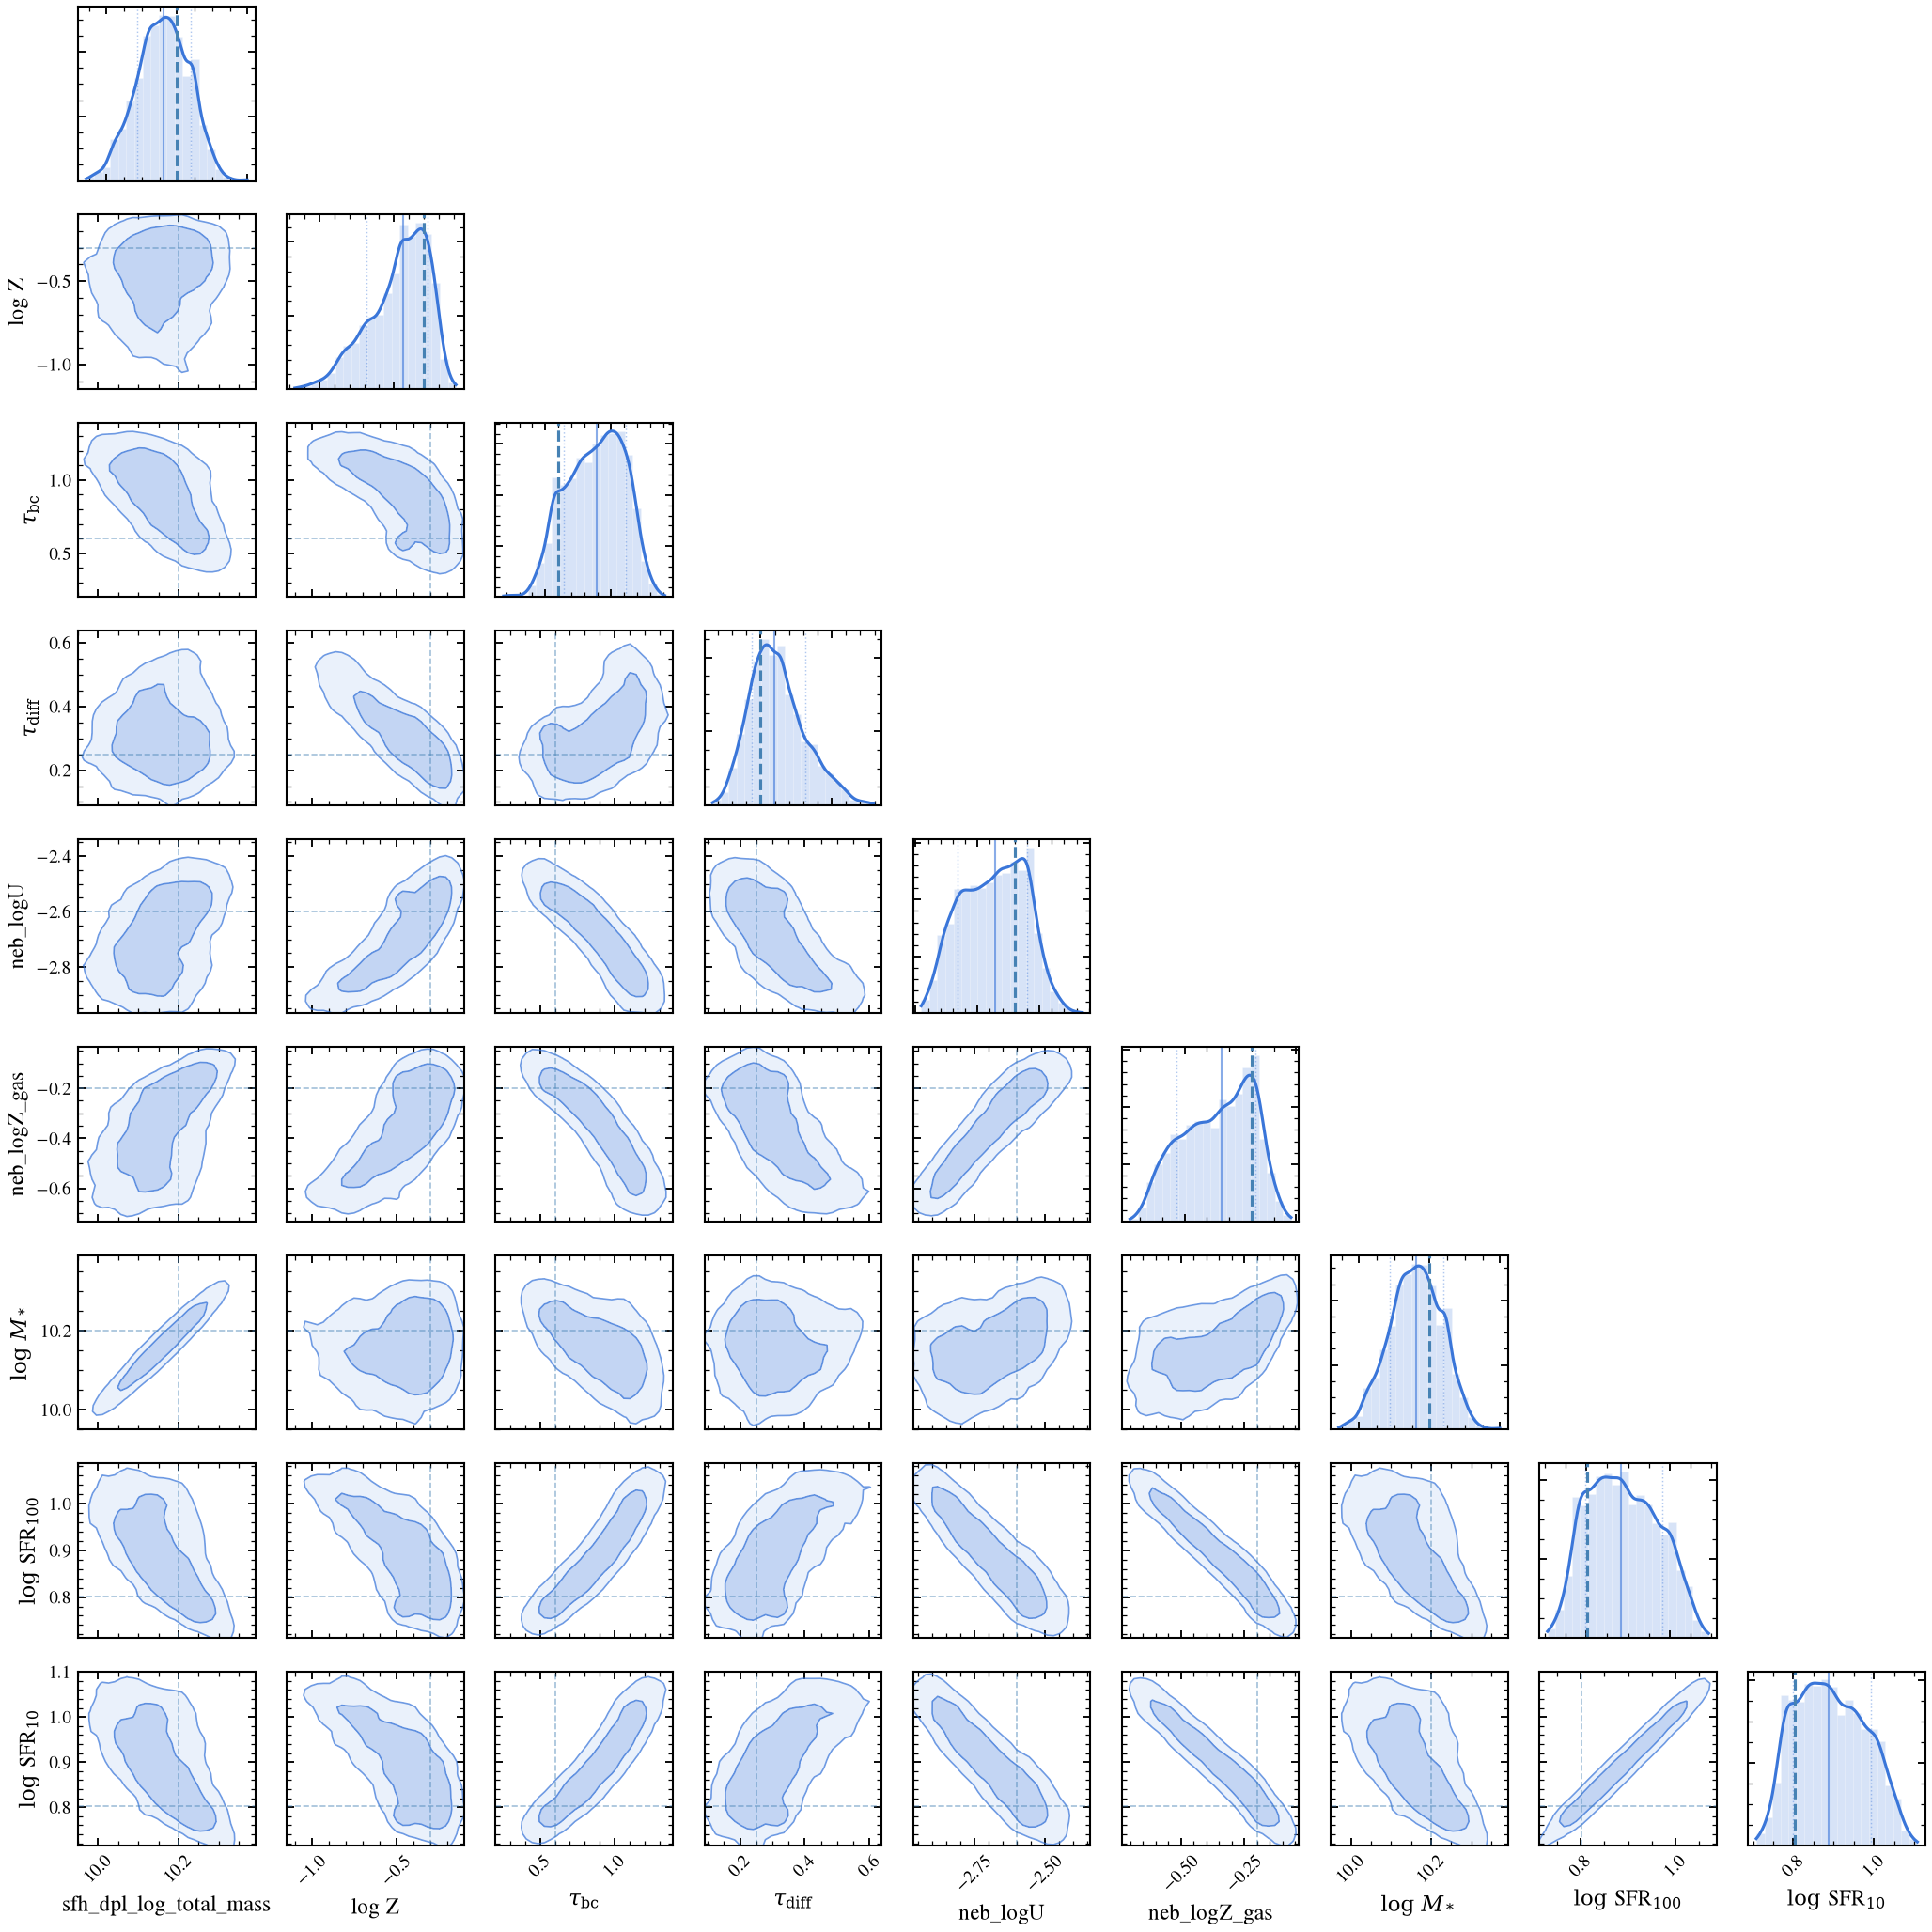

In [8]:
fig_corner = posterior.plot_corner(
    params=REPORT, truths={k: float(v) for k, v in truth_full.items()}, color=C_POST
)
fig_corner.savefig(FIG_DIR / "10_corner.png", dpi=150, bbox_inches="tight")
plt.show()

## Posterior draws for the figures

Evaluated once and reused by both figures below: the model photometry
(`predict_photometry`), the full model SED (`predict(...).rest_sed()` → observed
`F_ν`), and the model line fluxes (`predict_line_fluxes`) — each drawn over the
posterior so the bands carry the parameter uncertainty.

In [9]:
N_DRAW = 80
_sidx = np.linspace(0, len(next(iter(posterior.samples.values()))) - 1, N_DRAW).astype(int)
_fixed = model_fast.spec.get_fixed_values()
draws = [{**_fixed, **{k: jnp.asarray(v[i]) for k, v in posterior.samples.items()}} for i in _sidx]

# Effective wavelength of each band (transmission-weighted), for placing the points.
wave_eff_um = effective_wavelengths_um(phot_obs)

# Model photometry per draw (the band-integrated F_nu the fit is matching).
phot_draws = np.stack([np.asarray(model_fast.predict_photometry(d)) for d in draws])
phot_lo, phot_med, phot_hi = np.percentile(phot_draws, [16, 50, 84], axis=0)

# Continuous model SED per draw: rest-frame L_nu -> observed F_nu (same recipe as
# notebook 07). Observed-frame grid spanning the DECam-to-WISE range.
DL = cosmology.luminosity_distance(Z_GAL)
WAVE_FULL = np.geomspace(2.0e3, 3.0e5, 800)  # observed frame [Å]  (0.2–30 µm)
w_full_um = WAVE_FULL / 1e4

# For SED evaluation, use WavePrecomp() alone (not FeaturePrecomp). FeaturePrecomp
# attaches a per-Q_H nebular grid that disables exact rest_sed(); WavePrecomp()
# alone is exact for rest_sed() while remaining LUT-fast for photometry.
model_sed = build(line_data, approx=WavePrecomp())


def _sed_fnu(p):
    lnu = np.interp(
        WAVE_FULL / (1.0 + Z_GAL),
        np.asarray(model_sed.wavelengths),
        np.asarray(model_sed.predict(p).rest_sed()),
    )
    return np.asarray(lnu_to_fnu(jnp.asarray(lnu), DL, Z_GAL))


sed_lo, sed_med, sed_hi = np.percentile(
    np.stack([_sed_fnu(p) for p in draws]), [16, 50, 84], axis=0
)
sed_truth = _sed_fnu(truth_full)

## Do the points match the best fit? — photometry

Observed photometry on the posterior-median SED. Lower panel is the pull `(O−M)/σ`:
inside ±1 (gray band) means the model reproduces that band within error. Reduced χ²
quantifies the overall photometric match.

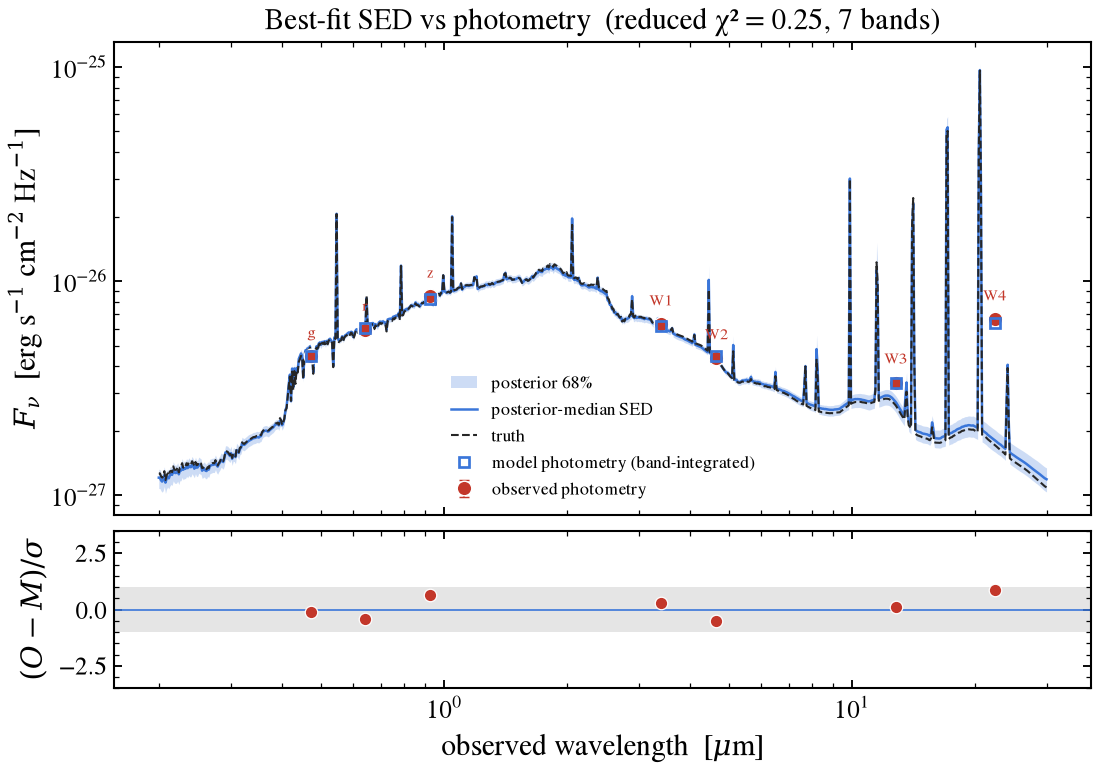

In [10]:
BAND_LABELS = ["g", "r", "z", "W1", "W2", "W3", "W4"]
pull_phot = (flux_phot - phot_med) / n_phot
chi2_phot = float(np.sum(pull_phot**2))

fig, (axs, axr) = plt.subplots(
    2, 1, figsize=(8.4, 5.6), sharex=True, gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)
axs.fill_between(w_full_um, sed_lo, sed_hi, color=C_POST, alpha=0.25, lw=0, label="posterior 68%")
axs.plot(w_full_um, sed_med, color=C_POST, lw=1.2, label="posterior-median SED")
axs.plot(w_full_um, sed_truth, color=C_TRUTH, lw=1.0, ls="--", label="truth")
axs.errorbar(
    wave_eff_um,
    flux_phot,
    yerr=n_phot,
    fmt="o",
    ms=7,
    color=C_DATA,
    mec="white",
    mew=0.7,
    elinewidth=1.1,
    capsize=2.5,
    zorder=6,
    label="observed photometry",
)
axs.plot(
    wave_eff_um,
    phot_med,
    marker="s",
    ms=5,
    ls="none",
    mfc="none",
    mec=C_POST,
    mew=1.3,
    zorder=7,
    label="model photometry (band-integrated)",
)
for name, x, y, e in zip(BAND_LABELS, wave_eff_um, flux_phot, n_phot):
    axs.annotate(
        name,
        (x, y + e),
        textcoords="offset points",
        xytext=(0, 7),
        ha="center",
        fontsize=7.5,
        color=C_DATA,
    )
axs.set_xscale("log")
axs.set_yscale("log")
axs.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
axs.set_title(
    f"Best-fit SED vs photometry  (reduced χ² = {chi2_phot / len(flux_phot):.2f}, 7 bands)"
)
axs.legend(frameon=False, fontsize=8.5, loc="lower center")

axr.axhspan(-1, 1, color="0.6", alpha=0.25, lw=0)
axr.axhline(0, color=C_POST, lw=0.8)
axr.plot(wave_eff_um, pull_phot, "o", ms=6, color=C_DATA, mec="white", mew=0.6)
axr.set_xscale("log")
axr.set_ylim(-3.5, 3.5)
axr.set_xlabel(r"observed wavelength  [$\mu$m]")
axr.set_ylabel(r"$(O-M)/\sigma$")
fig.savefig(FIG_DIR / "10_sed_photometry.png", dpi=300, bbox_inches="tight")
plt.show()

## Do the points match the best fit? — emission lines

Observed line fluxes against posterior-predictive predictions. Lines are categorical,
so no curve joins them — each is an independent measurement. Lower panel: pull over
the ten lines. Reduced χ² quantifies the line match.

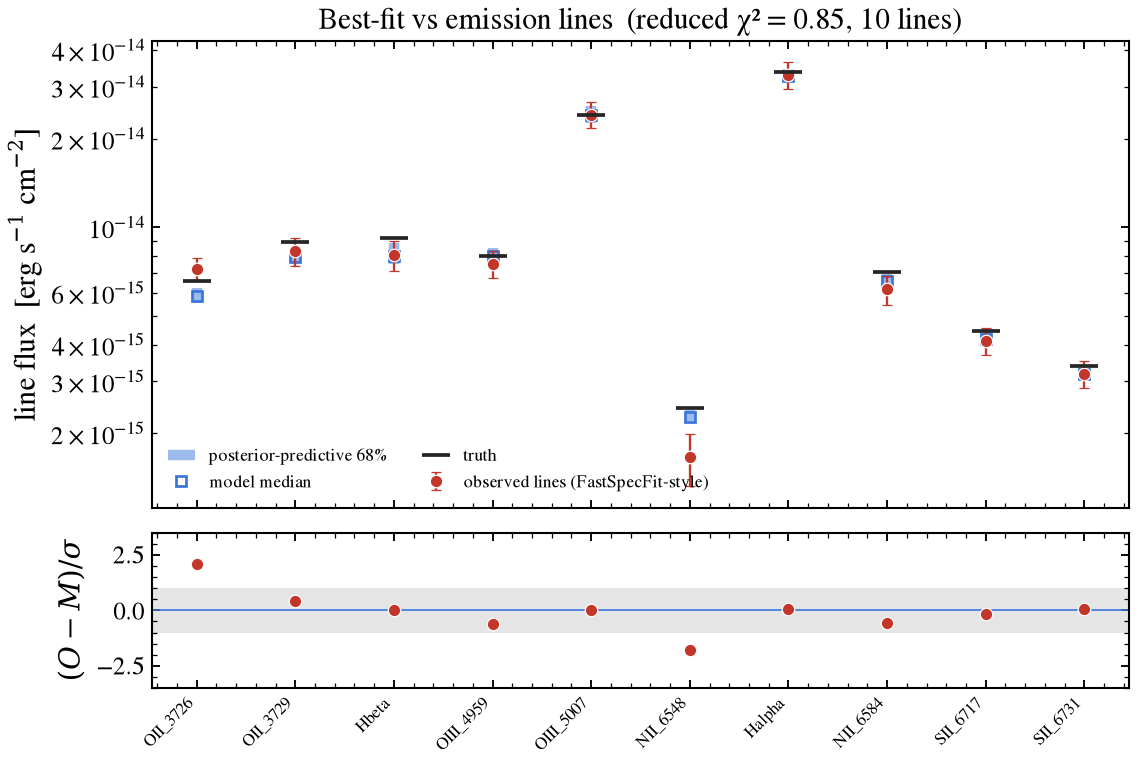

In [11]:
line_draws = np.stack(
    [np.asarray(model_fast.predict_line_fluxes(d, target_wavelengths=LINE_WAVES)) for d in draws]
)
line_lo, line_med, line_hi = np.percentile(line_draws, [16, 50, 84], axis=0)
pull_line = (flux_line - line_med) / n_line
chi2_line = float(np.sum(pull_line**2))
x = np.arange(len(LINE_NAMES))

fig, (axl, axp) = plt.subplots(
    2, 1, figsize=(8.4, 5.6), sharex=True, gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08}
)
axl.errorbar(
    x,
    flux_line,
    yerr=n_line,
    fmt="o",
    color=C_DATA,
    ms=6,
    mec="white",
    mew=0.6,
    elinewidth=1.1,
    capsize=2.5,
    zorder=4,
    label="observed lines (FastSpecFit-style)",
)
axl.vlines(
    x, line_lo, line_hi, color=C_POST, alpha=0.5, lw=5, zorder=2, label="posterior-predictive 68%"
)
axl.plot(
    x,
    line_med,
    marker="s",
    ms=5,
    ls="none",
    mfc="none",
    mec=C_POST,
    mew=1.3,
    zorder=3,
    label="model median",
)
axl.plot(x, p_line, marker="_", ms=13, mew=1.8, ls="none", color=C_TRUTH, zorder=5, label="truth")
axl.set_yscale("log")
axl.set_ylabel(r"line flux  [erg s$^{-1}$ cm$^{-2}$]")
axl.set_title(
    f"Best-fit vs emission lines  (reduced χ² = {chi2_line / len(LINE_NAMES):.2f}, 10 lines)"
)
axl.legend(fontsize=8.5, loc="lower left", ncol=2)

axp.axhspan(-1, 1, color="0.6", alpha=0.25, lw=0)
axp.axhline(0, color=C_POST, lw=0.8)
axp.plot(x, pull_line, "o", ms=6, color=C_DATA, mec="white", mew=0.6)
axp.set_ylim(-3.5, 3.5)
axp.set_ylabel(r"$(O-M)/\sigma$")
axp.set_xticks(x)
axp.set_xticklabels(LINE_NAMES, rotation=45, ha="right", fontsize=8)
fig.savefig(FIG_DIR / "10_line_recovery.png", dpi=300, bbox_inches="tight")
plt.show()

## Measured times, together

**`fit() wall`**: end-to-end cost of one call, including per-call JIT compile.
This is the interactive cost for fitting a single galaxy.
**`compiled step`** (`post.wall_time_s`): optimization loop time after compile.
This is the per-galaxy compute that a catalog pays after amortizing the compile via `fit_batch`.
It is the only metric where the fit path affects performance.

The attribution below is worth reading closely: the photometry lookup carries the
whole speed-up, and adding the nebular grid on top changes nothing. For a
photoionization backend like Cue, that grid earns its keep by standing in for the
emulator when the broadband flux is computed — which is only possible if nothing
downstream needs the nebular continuum. A dust component does need it, so on a
dusty model that saving is unavailable. The emission lines, meanwhile, are cheap
here on their own terms: dropping the line channel and re-measuring shows the ten
lines account for only about 8% of this fit's cost, so even a perfect line table
could not remove much. On a dust-free fit, or one without a photometry channel,
the balance changes — measure it there rather than carrying this result over.

In [12]:
print(f"{'fit':<34}{'fit() wall':>13}{'compiled step':>15}")
print("-" * 62)
print(f"{'MAP, exact wave grid':<34}{warm_e:>10.2f} s{loop_e:>12.2f} s")
print(f"{'MAP, WavePrecomp only':<34}{warm_w:>10.2f} s{loop_w:>12.2f} s")
print(f"{'MAP, WavePrecomp+FeaturePrecomp':<34}{warm_f:>10.2f} s{loop_f:>12.2f} s")
print(f"{'A/A control (exact, again)':<34}{'':>10}  {loop_aa:>12.2f} s")
print(f"\nNoise floor (A/A, same fit twice): {r_aa:.2f}x. Compiled-step ratio:")
print(f"{loop_e / loop_f:.2f}x overall — {loop_e / loop_w:.2f}x from WavePrecomp, a further")
print(
    f"{loop_w / loop_f:.2f}x from FeaturePrecomp; the overall ratio "
    + ("resolves" if resolved else "does not resolve")
    + " against the control."
)
print(f"The fit() wall (~{warm_f:.1f}s) is per-call JIT")
print("compile, not the fit — a catalog amortizes it once with fit_batch and pays only the")
print("compiled step per galaxy. The FeaturePrecomp nebular grid is likewise a one-time build")
print(
    f"({model_fast.spec.n_free}-parameter model), reused across every fit that shares the model."
)

fit                                  fit() wall  compiled step
--------------------------------------------------------------
MAP, exact wave grid                    3.93 s        3.59 s
MAP, WavePrecomp only                   1.86 s        1.64 s
MAP, WavePrecomp+FeaturePrecomp         1.86 s        1.65 s
A/A control (exact, again)                            3.60 s

Noise floor (A/A, same fit twice): 1.00x. Compiled-step ratio:
2.18x overall — 2.19x from WavePrecomp, a further
1.00x from FeaturePrecomp; the overall ratio resolves against the control.
The fit() wall (~1.9s) is per-call JIT
compile, not the fit — a catalog amortizes it once with fit_batch and pays only the
compiled step per galaxy. The FeaturePrecomp nebular grid is likewise a one-time build
(10-parameter model), reused across every fit that shares the model.


## Summary

- Fit FastSpecFit photometry + line fluxes through one `Observation` carrying both
  in `LineFluxData`. The fit automatically activates the line likelihood.
- Use `predict_line_fluxes` for pure, deblended, absorption-corrected emission
  (Gaussian on continuum-subtracted spectrum) matching `FastSpecFit.LINE_FLUX`.
  Window integrals are different: they carry stellar absorption and mis-deblend [N II].
- `WavePrecomp` and `FeaturePrecomp` are lookup tables, and `fit()` runs on them by
  default. On this fit the compiled step is 2.2x faster than the exact wave grid,
  and all of it is the photometry table: the nebular grid adds nothing measurable
  here. Its saving is a photometry one that a dusty model cannot take, and the ten
  emission lines add only about 8% to the cost of the fit in the first place, so a
  line table has little left to remove.
  At catalog scale (batched `fit_batch`) the one-time build is shared across galaxies.
- Stellar mass and SFR are well constrained. Metallicity / dust / gas conditions
  degenerate along the age–dust–metallicity ridge; the posterior width is the honest
  statement of that. Tighter constraints need a full spectrum, auroral line, or UV slope.
- Real catalogs: account for Cue's systematics (reproduces Cloudy to ~10%, ~30% for [S II]),
  fiber-aperture effects (line fluxes aperture-limited; photometry total), and dense mass
  matrix RAM cost (one fit per notebook process).